# 07 · Time-Series → Features → Gradient Boosting (LightGBM) — Retail Demand Forecasting

Everything so far let the **neural network** consume the raw sequence. This notebook shows the
**other dominant paradigm**, and the one you'll meet most often in consulting for *tabular*
forecasting:

> **Don't feed raw time to a deep net — engineer informative features from the time series, then
> let a gradient-boosted decision tree (LightGBM/XGBoost/CatBoost) do the prediction.**

For demand, pricing, supply-chain, energy-load and churn-style problems on small-to-medium data,
this approach is typically **faster, more robust, easier to explain, and frequently more
accurate** than an LSTM. It's the backbone of most winning Kaggle/M5 solutions and countless real
projects.

**The business problem (a classic engagement).** A retailer wants a **daily sales forecast** for
each *store-item* so they can plan inventory and staffing. Sales are driven by day-of-week,
seasonality, **price & promotions**, and holidays. We'll:

1. Simulate a realistic **multi-series** retail dataset (sales + price + promos + holidays).
2. **Engineer time-series features** the *leakage-safe* way (lags, rolling stats, calendar,
   promo/price, cyclical encodings).
3. Train a **single global LightGBM** across all series and beat strong naive baselines.
4. Read **feature importance** (the interpretability clients love).
5. Handle **multi-step forecasting** — *recursive* vs *direct* strategies.
6. Tour the **variants**: quantile intervals (uncertainty), global vs local models, automated
   features (`tsfresh`), and the **hybrid RNN-embedding → GBDT** that connects back to this series.

> 🔗 This is the counterpart to notebook 06: same forecasting goal, opposite philosophy. At the
> end we give a clear **"RNN vs GBDT vs hybrid"** decision guide.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

rng = np.random.default_rng(7)
pd.set_option("display.width", 120)
print("lightgbm", lgb.__version__)

lightgbm 4.6.0


## 1. Simulate a realistic retail dataset

We build **12 store-item series** over **2.5 years** of daily data. Each series has:

- a **base level** (some products sell more than others),
- a **weekly pattern** (weekends often busier),
- **yearly seasonality** (summer/winter effects),
- a slow **trend**,
- **promotions** — multi-day price cuts that spike demand (a *price elasticity* effect),
- **holiday** bumps,
- **Poisson noise** so sales are realistic integer counts.

Crucially, **price and promotions are *known in advance*** (the retailer plans them), so they are
legitimate future inputs — unlike future sales, which we must never peek at.

In [2]:
dates = pd.date_range("2022-01-01", "2024-06-30", freq="D")
n_days = len(dates)
n_series = 12

# a handful of fixed holidays (month, day) repeated each year -> demand bumps
holiday_md = {(1, 1), (7, 4), (8, 15), (11, 24), (12, 24), (12, 25), (12, 26)}
holiday_dates = pd.to_datetime([d for d in dates if (d.month, d.day) in holiday_md])

def make_promo_schedule(n):
    '''Multi-day promotions: occasionally start a 5-9 day price-cut event.'''
    promo = np.zeros(n, dtype=bool)
    i = 0
    while i < n:
        if rng.random() < 0.045:                 # ~ once every few weeks
            dur = int(rng.integers(5, 10))
            promo[i:i + dur] = True
            i += dur
        else:
            i += 1
    return promo

frames = []
for sid in range(n_series):
    base = rng.uniform(30, 120)                                    # product popularity
    dow_mult = np.array([0.9, 0.85, 0.9, 0.95, 1.1, 1.4, 1.3]) * rng.uniform(0.9, 1.1, 7)
    year_amp = rng.uniform(0.10, 0.35)
    year_phase = rng.uniform(0, 2 * np.pi)
    trend = rng.uniform(-0.03, 0.10)                              # total relative growth over the span
    elasticity = rng.uniform(1.6, 3.2)                            # demand multiplier while on promo
    base_price = rng.uniform(5, 25)

    doy = dates.dayofyear.to_numpy()
    dow = dates.dayofweek.to_numpy()
    t = np.arange(n_days)

    weekly = dow_mult[dow]
    yearly = 1 + year_amp * np.sin(2 * np.pi * doy / 365.25 + year_phase)
    trendf = 1 + trend * (t / n_days)
    on_promo = make_promo_schedule(n_days)
    price = base_price * np.where(on_promo, 0.75, 1.0) * rng.uniform(0.98, 1.02, n_days)
    promo_mult = np.where(on_promo, elasticity, 1.0)
    hol_mult = np.where(np.isin(dates, holiday_dates), 1.5, 1.0)

    expected = base * weekly * yearly * trendf * promo_mult * hol_mult
    sales = rng.poisson(np.clip(expected, 1, None))               # integer, count-like demand

    frames.append(pd.DataFrame({
        "date": dates, "series_id": sid, "sales": sales,
        "price": price.round(2), "on_promo": on_promo.astype(int),
    }))

df = pd.concat(frames, ignore_index=True)
print("panel shape:", df.shape, "|", n_series, "series x", n_days, "days")
df.head()

panel shape: (10944, 5) | 12 series x 912 days


,date,series_id,sales,price,on_promo
0,2022-01-01,0,174,9.92,0
1,2022-01-02,0,147,9.98,0
2,2022-01-03,0,85,9.95,0
3,2022-01-04,0,70,10.08,0
4,2022-01-05,0,84,10.04,0


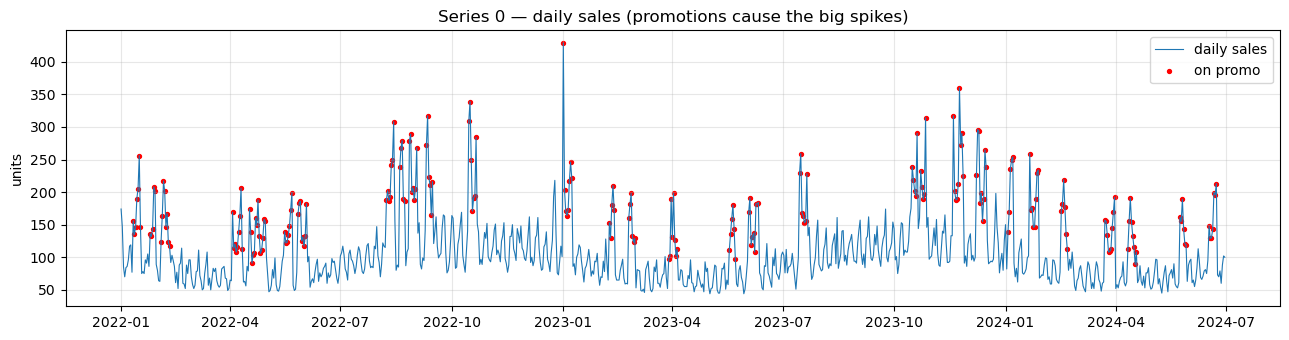

In [3]:
# look at one series: notice weekly wiggle, yearly wave, and promo spikes (red)
one = df[df.series_id == 0]
plt.figure(figsize=(13, 3.5))
plt.plot(one["date"], one["sales"], lw=0.8, label="daily sales")
promo_days = one[one.on_promo == 1]
plt.scatter(promo_days["date"], promo_days["sales"], color="red", s=8, label="on promo")
plt.title("Series 0 — daily sales (promotions cause the big spikes)")
plt.ylabel("units"); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 2. Feature engineering — the heart of the approach (and where leakage kills projects)

A tree model has **no notion of time** — it sees each row independently. So we must **hand it the
temporal context as columns**. The families of features:

| Family | Examples | Captures |
|---|---|---|
| **Lags** | sales 1, 7, 14, 28 days ago | recent level, weekly echo |
| **Rolling stats** | mean/std over last 7 & 28 days | local level & volatility |
| **Calendar** | day-of-week, month, day, week-of-year, weekend, holiday | seasonality & special days |
| **Cyclical** | sin/cos of day-of-year | smooth yearly seasonality |
| **Known covariates** | price, promo flag, price lag | planned demand drivers |
| **Series id** | which store-item | lets one global model specialize per series |

> ⚠️ **The #1 mistake: data leakage.** Every feature for the row at date *t* must use **only
> information available strictly before selling happens at *t***. Two rules enforce this:
> 1. Lag/rolling features are computed **per series** (`groupby('series_id')`) so one product's
>    history never bleeds into another's.
> 2. Rolling windows are applied to a **shifted** series (`.shift(1)`) so today's own sales are
>    excluded from today's features.
>
> Price and promo are exceptions — they're *known in advance*, so using the current day's value is
> legitimate, not leakage.

In [4]:
def build_features(data):
    '''Create leakage-safe time-series features. Works on the full panel OR a single series,
       because every lag/rolling op is grouped by series_id.'''
    d = data.sort_values(["series_id", "date"]).copy()
    g = d.groupby("series_id")["sales"]

    # --- lags: sales N days ago (per series) ---
    for lag in [1, 7, 14, 28]:
        d[f"sales_lag_{lag}"] = g.shift(lag)

    # --- rolling stats on the SHIFTED series (so 'today' is excluded -> no leakage) ---
    for w in [7, 28]:
        d[f"sales_rmean_{w}"] = g.transform(lambda s: s.shift(1).rolling(w).mean())
        d[f"sales_rstd_{w}"]  = g.transform(lambda s: s.shift(1).rolling(w, min_periods=2).std())

    # --- known covariates: price & promo (allowed at current day) + a price lag ---
    d["price_lag_1"] = d.groupby("series_id")["price"].shift(1)

    # --- calendar features ---
    dt = d["date"].dt
    d["dow"] = dt.dayofweek
    d["month"] = dt.month
    d["day"] = dt.day
    d["weekofyear"] = dt.isocalendar().week.astype(int)
    d["is_weekend"] = (d["dow"] >= 5).astype(int)
    d["is_holiday"] = d["date"].isin(holiday_dates).astype(int)

    # --- cyclical yearly encoding (smooth, no artificial Dec->Jan jump) ---
    d["doy_sin"] = np.sin(2 * np.pi * dt.dayofyear / 365.25)
    d["doy_cos"] = np.cos(2 * np.pi * dt.dayofyear / 365.25)
    return d

feat = build_features(df)

FEATURES = [
    "series_id",
    "sales_lag_1", "sales_lag_7", "sales_lag_14", "sales_lag_28",
    "sales_rmean_7", "sales_rstd_7", "sales_rmean_28", "sales_rstd_28",
    "price", "price_lag_1", "on_promo",
    "dow", "month", "day", "weekofyear", "is_weekend", "is_holiday",
    "doy_sin", "doy_cos",
]
CATEGORICAL = ["series_id", "dow", "month"]   # tell LightGBM to treat these as categories
TARGET = "sales"

print("engineered features:", len(FEATURES))
feat[["date", "series_id", "sales", "sales_lag_1", "sales_lag_7",
      "sales_rmean_7", "price", "on_promo", "dow", "is_holiday"]].head(9)

engineered features: 20


,date,series_id,sales,sales_lag_1,sales_lag_7,sales_rmean_7,price,on_promo,dow,is_holiday
0,2022-01-01,0,174,NaN,NaN,NaN,9.92,0,5,1
1,2022-01-02,0,147,174.0,NaN,NaN,9.98,0,6,0
2,2022-01-03,0,85,147.0,NaN,NaN,9.95,0,0,0
3,2022-01-04,0,70,85.0,NaN,NaN,10.08,0,1,0
4,2022-01-05,0,84,70.0,NaN,NaN,10.04,0,2,0
5,2022-01-06,0,86,84.0,NaN,NaN,10.13,0,3,0
6,2022-01-07,0,96,86.0,NaN,NaN,10.01,0,4,0
7,2022-01-08,0,117,96.0,174.0,106.000000,9.91,0,5,0
8,2022-01-09,0,119,117.0,147.0,97.857143,10.03,0,6,0


## 3. Split by TIME (never randomly) and train a single global LightGBM

- **Train** = everything before 2024-01-01, **validation** = Jan–Mar 2024, **test** = Apr–Jun 2024.
  Splitting by date mimics reality: we always predict the *future* from the *past*.
- We drop the first rows of each series where lag features are still `NaN` (no history yet).
- **One global model** is trained across *all* series at once. It learns shared patterns (weekend
  effect, promo elasticity) while the `series_id` feature lets it specialize per product. This
  "global model" trick is the modern default — far better than fitting 12 tiny separate models.
- Target here is **next available day's sales given past-derived features** (a 1-step relationship);
  we tackle true multi-step horizons in §6.

In [5]:
valid_start = pd.Timestamp("2024-01-01")
test_start  = pd.Timestamp("2024-04-01")

model_df = feat.dropna(subset=[f"sales_lag_{l}" for l in [1, 7, 14, 28]] +
                              ["sales_rmean_28"]).copy()

train = model_df[model_df.date < valid_start]
valid = model_df[(model_df.date >= valid_start) & (model_df.date < test_start)]
test  = model_df[model_df.date >= test_start]
print(f"train {len(train):,} | valid {len(valid):,} | test {len(test):,} rows")

def XY(part): return part[FEATURES], part[TARGET]
X_tr, y_tr = XY(train); X_va, y_va = XY(valid); X_te, y_te = XY(test)

model = lgb.LGBMRegressor(
    n_estimators=800, learning_rate=0.05, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8, min_child_samples=40,
    random_state=7, n_jobs=-1,
)
model.fit(
    X_tr, y_tr,
    eval_set=[(X_va, y_va)], eval_metric="l1",
    categorical_feature=CATEGORICAL,
    callbacks=[lgb.early_stopping(60), lgb.log_evaluation(0)],
)
print("best iteration (early-stopped):", model.best_iteration_)

train 8,424 | valid 1,092 | test 1,092 rows
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001586 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3178
[LightGBM] [Info] Number of data points in the train set: 8424, number of used features: 20


[LightGBM] [Info] Start training from score 124.111705
Training until validation scores don't improve for 60 rounds


Early stopping, best iteration is:
[278]	valid_0's l1: 11.3367	valid_0's l2: 247.633
best iteration (early-stopped): 278


## 4. Evaluate against the baselines a client will demand

As always, a model only earns its complexity by **beating trivial baselines**:

- **Naive** — tomorrow = today (`sales_lag_1`).
- **Seasonal naive** — same day last week (`sales_lag_7`); strong when weekly seasonality rules.
- **Moving average** — mean of last 7 days (`sales_rmean_7`).

In [6]:
def scores(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred), np.sqrt(mean_squared_error(y_true, y_pred))

pred_gbdt = model.predict(X_te)
results = {
    "Naive (yesterday)"       : test["sales_lag_1"].values,
    "Seasonal naive (last wk)": test["sales_lag_7"].values,
    "Moving average (7d)"     : test["sales_rmean_7"].values,
    "LightGBM (features)"     : pred_gbdt,
}
print(f"{'model':<28}{'MAE':>8}{'RMSE':>8}")
for name, pred in results.items():
    mae, rmse = scores(y_te, pred)
    print(f"{name:<28}{mae:>8.2f}{rmse:>8.2f}")
print("\nLower is better — the engineered-feature GBDT should clearly win.")

model                            MAE    RMSE


Naive (yesterday)              30.89   55.29
Seasonal naive (last wk)       59.68   97.74
Moving average (7d)            44.87   71.31
LightGBM (features)            11.13   15.77

Lower is better — the engineered-feature GBDT should clearly win.


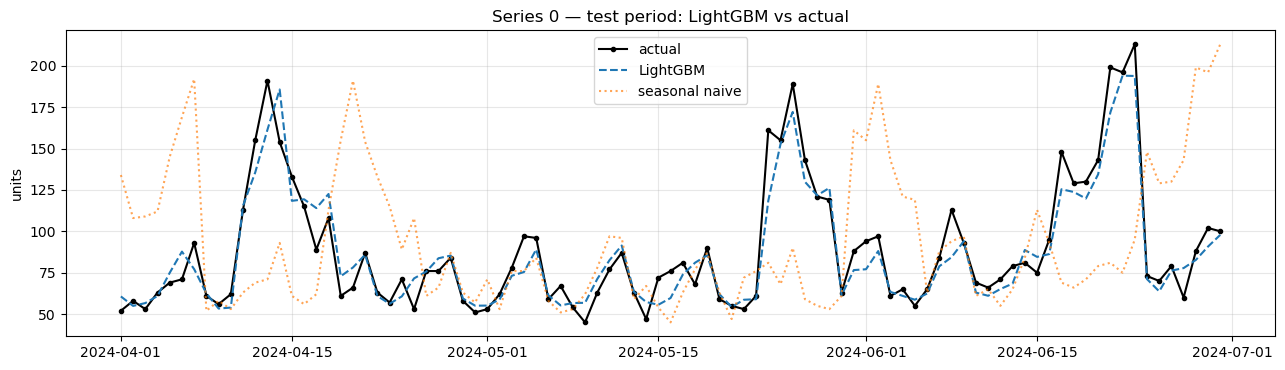

In [7]:
# visualize: actual vs LightGBM for one series over the test window
sid = 0
mask = test.series_id == sid
sub = test[mask].sort_values("date")
plt.figure(figsize=(13, 3.8))
plt.plot(sub["date"], sub["sales"], "k-o", ms=3, label="actual")
plt.plot(sub["date"], model.predict(sub[FEATURES]), "--", label="LightGBM")
plt.plot(sub["date"], sub["sales_lag_7"], ":", alpha=0.7, label="seasonal naive")
plt.title(f"Series {sid} — test period: LightGBM vs actual"); plt.ylabel("units")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 5. Interpretability — feature importance

A huge selling point of GBDTs over deep nets in consulting: you can **explain** the drivers.
LightGBM reports how often/effectively each feature was used to split. (For rigorous, per-
prediction explanations you'd use **SHAP** values on top — worth knowing, not needed here.)

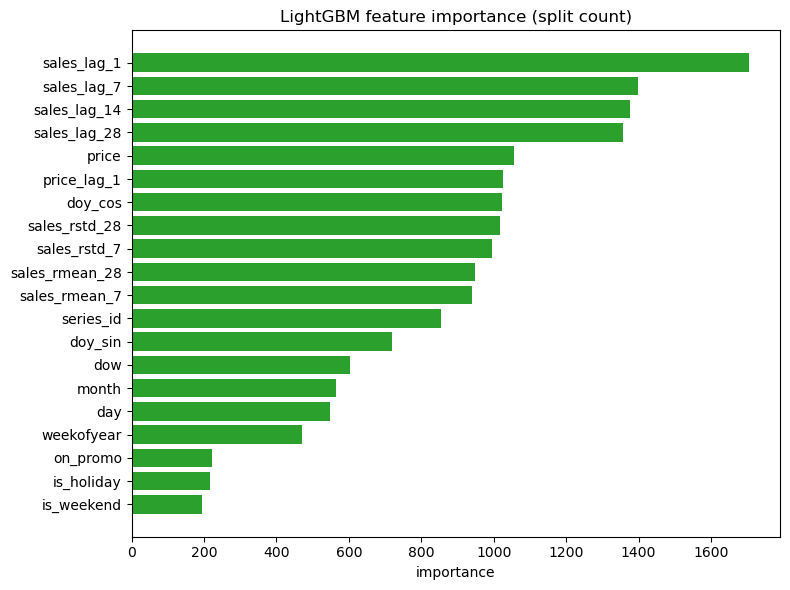

Typically the recent lag, weekly lag/rolling mean, promo/price and calendar features
dominate — matching how the data was actually generated. Good sanity check!


In [8]:
imp = (pd.Series(model.feature_importances_, index=FEATURES)
       .sort_values(ascending=True))
plt.figure(figsize=(8, 6))
plt.barh(imp.index, imp.values, color="#2ca02c")
plt.title("LightGBM feature importance (split count)")
plt.xlabel("importance"); plt.tight_layout(); plt.show()
print("Typically the recent lag, weekly lag/rolling mean, promo/price and calendar features")
print("dominate — matching how the data was actually generated. Good sanity check!")

## 6. Multi-step forecasting: *recursive* vs *direct*

The evaluation above used **true** lag values, i.e. a 1-step-ahead relationship. But a client
usually wants a whole horizon (say **28 days**) forecast *now*, when future sales — and thus
future `sales_lag_1` — **don't exist yet**. Two standard strategies solve this:

**A) Recursive (iterative).** Predict day 1, treat that prediction as if it were real, rebuild
features, predict day 2, and so on. *Pros:* one model, uses the most recent lag. *Cons:* errors
**compound** across the horizon.

**B) Direct.** Train a **separate model per horizon** (a "predict 7 days ahead" model uses only
lags ≥ 7, a "14 days ahead" model uses lags ≥ 14, …). *Pros:* no compounding; each horizon
optimized directly. *Cons:* many models to train and maintain.

Real systems often **blend** them (e.g. direct for key horizons, recursive to fill in). Let's
implement the **recursive** rollout, run it for **every series** from a single forecast origin
(the train/test split), and honestly measure how the error behaves **as we predict further ahead**
— compared to a proper multi-step **seasonal-naive** baseline (repeat the last known week).

In [9]:
def recursive_forecast(history, future, model):
    '''Forecast `future` dates for a SINGLE series by feeding predictions back in.
       history: past rows (sales known). future: rows with known price/promo, sales unknown.'''
    work = pd.concat([history, future], ignore_index=True).sort_values("date").reset_index(drop=True)
    preds = []
    for d in future["date"]:
        f = build_features(work)                 # recompute features from the growing history
        x = f.loc[f.date == d, FEATURES]
        p = max(float(model.predict(x)[0]), 0.0) # sales can't be negative
        work.loc[work.date == d, "sales"] = p    # write prediction back so next day can lag on it
        preds.append(p)
    return np.array(preds)

# roll every series forward from the split and collect per-horizon-day absolute errors
abs_gbdt, abs_snaive, example = [], [], None
for sid in range(n_series):
    s = df[df.series_id == sid]
    hist = s[s.date < test_start].copy()
    fut  = s[s.date >= test_start].copy()
    rec = recursive_forecast(hist, fut.assign(sales=np.nan), model)   # true multi-step, no leakage
    # multi-step seasonal naive = tile the last known 7 days across the whole horizon
    last7 = hist["sales"].values[-7:]
    snaive = np.tile(last7, int(np.ceil(len(fut) / 7)))[:len(fut)]
    abs_gbdt.append(np.abs(rec - fut["sales"].values))
    abs_snaive.append(np.abs(snaive - fut["sales"].values))
    if sid == 0:
        example = (fut["date"].values, fut["sales"].values, rec)

abs_gbdt, abs_snaive = np.array(abs_gbdt), np.array(abs_snaive)
print(f"Whole-horizon recursive MAE  — LightGBM: {abs_gbdt.mean():.2f}"
      f"   |   seasonal-naive: {abs_snaive.mean():.2f}")
print("The recursive GBDT, forecasting the entire horizon with NO access to future sales,")
print("still beats the seasonal-naive baseline by a wide margin.")

Whole-horizon recursive MAE  — LightGBM: 13.96   |   seasonal-naive: 58.52
The recursive GBDT, forecasting the entire horizon with NO access to future sales,
still beats the seasonal-naive baseline by a wide margin.


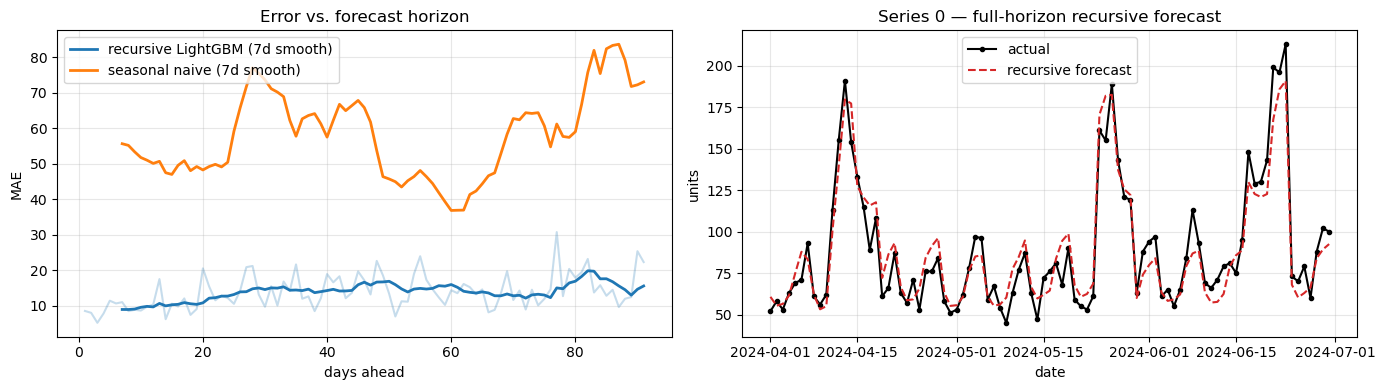

Read the left panel: with strong weekly/seasonal features the recursive error stays
fairly stable rather than exploding — but any upward drift with horizon is the
compounding effect, and it's exactly what a DIRECT (per-horizon) model avoids.


In [10]:
# (a) error vs. days-ahead — does recursion compound? (b) an example series forecast
mae_g = abs_gbdt.mean(0)      # mean over series, per horizon day
mae_s = abs_snaive.mean(0)
days = np.arange(1, len(mae_g) + 1)
def smooth(a, k=7): return np.convolve(a, np.ones(k) / k, mode="valid")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(days, mae_g, alpha=0.25, color="#1f77b4")
ax1.plot(days[6:], smooth(mae_g), color="#1f77b4", lw=2, label="recursive LightGBM (7d smooth)")
ax1.plot(days[6:], smooth(mae_s), color="#ff7f0e", lw=2, label="seasonal naive (7d smooth)")
ax1.set_title("Error vs. forecast horizon"); ax1.set_xlabel("days ahead"); ax1.set_ylabel("MAE")
ax1.legend(); ax1.grid(alpha=0.3)

dts, actual, rec = example
ax2.plot(dts, actual, "k-o", ms=3, label="actual")
ax2.plot(dts, rec, "--", color="#d62728", label="recursive forecast")
ax2.set_title("Series 0 — full-horizon recursive forecast"); ax2.set_xlabel("date")
ax2.set_ylabel("units"); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("Read the left panel: with strong weekly/seasonal features the recursive error stays")
print("fairly stable rather than exploding — but any upward drift with horizon is the")
print("compounding effect, and it's exactly what a DIRECT (per-horizon) model avoids.")

## 7. Variant — probabilistic forecasts (quantile / prediction intervals)

Clients rarely want a single number; they want a **range** to manage risk ("stock enough to cover
the 90th-percentile demand"). LightGBM can predict **quantiles** directly by switching the
objective. Train one model per quantile (e.g. p10 / p50 / p90) to get a prediction band — a big,
practical value-add over a bare point forecast.

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001446 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3178
[LightGBM] [Info] Number of data points in the train set: 8424, number of used features: 20
[LightGBM] [Info] Start training from score 45.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002816 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3178
[LightGBM] [Info] Number of data points in the train set: 8424, number of used features: 20
[LightGBM] [Info] Start training from score 100.000000


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001764 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3178
[LightGBM] [Info] Number of data points in the train set: 8424, number of used features: 20
[LightGBM] [Info] Start training from score 242.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

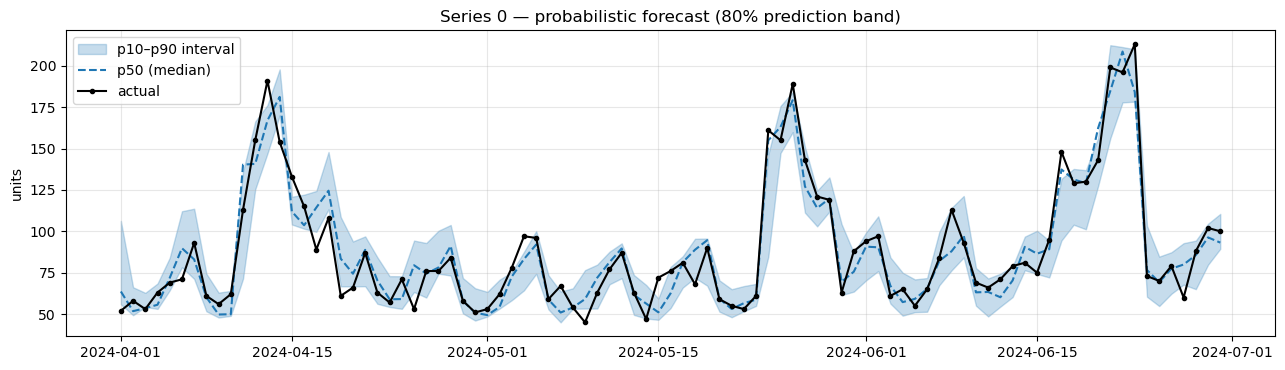

Empirical coverage of the p10–p90 band: 71%  (target ≈ 80%)


In [11]:
def train_quantile(alpha):
    m = lgb.LGBMRegressor(objective="quantile", alpha=alpha, n_estimators=400,
                          learning_rate=0.05, num_leaves=63, min_child_samples=40,
                          random_state=7, n_jobs=-1)
    m.fit(X_tr, y_tr, categorical_feature=CATEGORICAL,
          callbacks=[lgb.log_evaluation(0)])
    return m

q10, q50, q90 = (train_quantile(a) for a in (0.1, 0.5, 0.9))

sid = 0
sub = test[test.series_id == sid].sort_values("date")
p10, p50, p90 = (m.predict(sub[FEATURES]) for m in (q10, q50, q90))

plt.figure(figsize=(13, 3.8))
plt.fill_between(sub["date"], p10, p90, alpha=0.25, color="#1f77b4",
                 label="p10–p90 interval")
plt.plot(sub["date"], p50, "--", color="#1f77b4", label="p50 (median)")
plt.plot(sub["date"], sub["sales"], "k-o", ms=3, label="actual")
plt.title(f"Series {sid} — probabilistic forecast (80% prediction band)")
plt.ylabel("units"); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

coverage = ((sub["sales"].values >= p10) & (sub["sales"].values <= p90)).mean()
print(f"Empirical coverage of the p10–p90 band: {coverage:.0%}  (target ≈ 80%)")

## 8. Other variants you should know (and when to reach for them)

**Global vs. local models.** We trained *one* global model with `series_id` as a feature. For a
handful of long, very different series a **local** (per-series) model can win; with **many** series
(hundreds/thousands, often short) the **global** model almost always wins — it shares statistical
strength across series. Global-first is the modern default.

**Automated feature extraction (`tsfresh`, `tsfel`).** Instead of hand-writing lags/rolls, these
libraries compute *hundreds* of statistical descriptors per window (autocorrelation, spectral
entropy, peak counts, trend slopes…), then you select the useful ones and feed a GBDT. Great when
you don't know which features matter (e.g. sensor/vibration classification like notebook 04).
*(Not installed here — `pip install tsfresh` — but the pattern is: window → tsfresh features →
LightGBM.)*

**Direct global multi-horizon.** Add the **horizon `h` as a feature** and train on
(features, h) → sales_{t+h} pairs across all h. One model covers the whole horizon without a
per-day compounding loop — a popular middle ground.

**Cross-validation for time series.** Never use plain k-fold (it leaks the future). Use an
**expanding-window** scheme (`sklearn.model_selection.TimeSeriesSplit`): train on [0..k], validate
on [k..k+1], slide forward. It gives an honest estimate of forward-looking error.

In [12]:
# illustrate proper time-series cross-validation folds (expanding window)
from sklearn.model_selection import TimeSeriesSplit
unique_days = np.sort(model_df["date"].unique())
tscv = TimeSeriesSplit(n_splits=4)
print("Expanding-window CV over the timeline (train always precedes validation):\n")
for i, (tr_idx, va_idx) in enumerate(tscv.split(unique_days), 1):
    tr_days, va_days = unique_days[tr_idx], unique_days[va_idx]
    print(f"  fold {i}: train {pd.Timestamp(tr_days[0]).date()}..{pd.Timestamp(tr_days[-1]).date()}"
          f"  ->  valid {pd.Timestamp(va_days[0]).date()}..{pd.Timestamp(va_days[-1]).date()}")

Expanding-window CV over the timeline (train always precedes validation):

  fold 1: train 2022-01-29..2022-07-27  ->  valid 2022-07-28..2023-01-19
  fold 2: train 2022-01-29..2023-01-19  ->  valid 2023-01-20..2023-07-14
  fold 3: train 2022-01-29..2023-07-14  ->  valid 2023-07-15..2024-01-06
  fold 4: train 2022-01-29..2024-01-06  ->  valid 2024-01-07..2024-06-30


## 9. The hybrid: **RNN embedding → GBDT** (connecting both worlds)

Your original question hinted at this: use an RNN to *extract information from the sequence*, then
let a GBDT make the final prediction. It's a real (if specialized) **stacking** pattern:

1. Train an RNN/LSTM (or an autoencoder) on the raw sequences.
2. Take a learned **embedding** — e.g. the encoder's final hidden state — as a fixed-length vector
   summarizing each window.
3. **Concatenate** that embedding with the hand-crafted tabular features (price, calendar, promo…).
4. Train **LightGBM** on the combined table.

*Why:* the RNN captures subtle sequential shape that's hard to hand-engineer, while the GBDT excels
at mixing that with heterogeneous tabular covariates and static attributes. *When:* the raw signal
is genuinely complex/high-frequency (waveforms, clickstreams, text) **and** simple lag features
leave accuracy on the table. Below is the *shape* of it in code (illustrative — we reuse the
encoder idea from notebook 06).

In [13]:
# ---- Illustrative sketch of the hybrid (concept, kept tiny) ----
# Suppose `encoder` is a trained RNN encoder that maps a (window, features) sequence to a hidden
# vector. We'd produce embeddings for each row's preceding window and glue them onto the features:
#
#   emb = encoder(past_window_tensor)          # (n_rows, hidden)  learned sequence summary
#   X_hybrid = np.hstack([X_features.values, emb])   # tabular features + RNN embedding
#   lgb.LGBMRegressor().fit(X_hybrid, y)             # GBDT on the combined representation
#
# Here we just MOCK an embedding with a rolling-shape descriptor to show the plumbing runs.
def mock_embedding(part, dim=4):
    # stand-in for a real RNN encoder output: a few extra shape descriptors of recent sales
    base = part[["sales_rmean_7", "sales_rstd_7", "sales_lag_1", "sales_lag_28"]].fillna(0).values
    return base[:, :dim]

X_tr_h = np.hstack([X_tr.values, mock_embedding(train)])
X_te_h = np.hstack([X_te.values, mock_embedding(test)])
hybrid = lgb.LGBMRegressor(n_estimators=400, learning_rate=0.05, num_leaves=63,
                           min_child_samples=40, random_state=7, n_jobs=-1)
hybrid.fit(X_tr_h, y_tr, callbacks=[lgb.log_evaluation(0)])
mae_h, _ = scores(y_te, hybrid.predict(X_te_h))
print(f"Hybrid (features + mock embedding) MAE: {mae_h:.2f}")
print("(With a REAL trained RNN encoder in place of the mock, this is the full recipe.)")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002367 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4196
[LightGBM] [Info] Number of data points in the train set: 8424, number of used features: 24
[LightGBM] [Info] Start training from score 124.111705


Hybrid (features + mock embedding) MAE: 12.02
(With a REAL trained RNN encoder in place of the mock, this is the full recipe.)


## 10. Decision guide — RNN vs GBDT-on-features vs Hybrid

| Use... | When |
|---|---|
| **GBDT on engineered features** *(this notebook)* | Tabular forecasting/classification, small–medium data, many exogenous covariates (price, promo, calendar), need speed + interpretability. **The default for most business time-series.** |
| **RNN / LSTM / GRU** *(notebooks 02–06)* | Long, high-frequency raw sequences; complex temporal shape hard to hand-feature; lots of data; low-latency streaming; end-to-end learning of the sequence. |
| **Hybrid (RNN embedding → GBDT)** *(§9)* | Rich sequential signal **and** important tabular covariates; you've squeezed hand-features and want the extra lift; willing to maintain two models. |
| **Modern deep forecasters** (TFT, N-HiTS, DeepAR) | Large multi-series datasets needing probabilistic, multi-horizon deep models with covariates. |

**Practical order of attack on a new engagement:**
1. Baselines (naive / seasonal naive).
2. **GBDT on engineered features** — fast, strong, explainable. *Usually where you stop.*
3. Add quantiles for uncertainty; proper time-series CV.
4. Only if the sequence signal is rich and unmet: try an **RNN/deep model** or the **hybrid**.

## 11. Recap

- For most tabular/business time series, the winning move is **engineer features → LightGBM**, not
  a deep net.
- **Leakage discipline** (group by series, shift before rolling, split by time) is what separates a
  real model from a fantasy one.
- A **global** model with `series_id` + calendar + lags + promo/price beats naive baselines and is
  **interpretable**.
- Handle horizons with **recursive** or **direct** strategies; quantify uncertainty with
  **quantile** models; validate with **expanding-window CV**.
- The **RNN→GBDT hybrid** is a legitimate, if specialized, way to combine both paradigms.

Together with notebooks 01–06 you now command **both** major approaches to sequence problems — and,
just as importantly, **when to use which**.